<a href="https://colab.research.google.com/github/Egg-Lord/CCMACLRL_EXERCISES_COM232/blob/main/Exercise5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 5: Create your own personal face recognition using SVM

## Instructions:

Create a directory in your google drive using this folder structure

```
My Drive
- Images
  - Train
    - Elizer
    - Eliza
  - Test
```

- Upload 90 images of your self (selfied are recommended) in the Train folder
- Upload 90 images of your partner in the Train folder
- Upload 20 images of yourself and your partner in the Test Folder
- Use **.png** or **.jpg** or **.jpeg** images files

In [1]:
pip install numpy opencv-python scikit-learn

## Import libraries

In [2]:
import os
import cv2
import numpy as np
from PIL import Image  # PIL is used to load the image
import matplotlib.pyplot as plt

## Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pillow-heif

import os
from PIL import Image
import pillow_heif

input_folder = '/content/drive/My Drive/images_rid/Train/Xen'
for filename in os.listdir(input_folder):
    if filename.lower().endswith('.heic'):
        heic_path = os.path.join(input_folder, filename)
        jpg_path = os.path.splitext(heic_path)[0] + ".jpg"

        heif_file = pillow_heif.read_heif(heic_path)
        image = Image.frombytes(
            heif_file.mode,
            heif_file.size,
            heif_file.data,
            "raw"
        )
        image.save(jpg_path, "JPEG")
        print(f"Converted: {filename} -> {os.path.basename(jpg_path)}")

print("✅ Conversion complete!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 40.4 MB/s eta 0:00:00
Converted: Copy of IMG_7068.HEIC -> Copy of IMG_7068.jpg
Converted: Copy of IMG_5752.HEIC -> Copy of IMG_5752.jpg
Converted: Copy of IMG_7963.HEIC -> Copy of IMG_7963.jpg
Converted: Copy of IMG_8441.HEIC -> Copy of IMG_8441.jpg
Converted: Copy of IMG_8381.HEIC -> Copy of IMG_8381.jpg
Converted: Copy of IMG_9161.HEIC -> Copy of IMG_9161.jpg
Converted: Copy of IMG_2859.HEIC -> Copy of IMG_2859.jpg
Converted: Copy of IMG_1600.HEIC -> Copy of IMG_1600.jpg
Converted: Copy of IMG_4659.HEIC -> Copy of IMG_4659.jpg
Converted: Copy of IMG_1825.HEIC -> Copy of IMG_1825.jpg
Converted: Copy of IMG_1598.HEIC -> Copy of IMG_1598.jpg
Converted: Copy of IMG_3852.HEIC -> Copy of IMG_3852.jpg
Converted: Copy of IMG_3843.HEIC -> Copy of IMG_3843.jpg
Converted: Copy of IMG_8221.HEIC -> Copy of IMG_8221.jpg
Converted: Copy of IMG_0946.HEIC -> Copy of IMG_0946.jpg
Converted: Copy of IMG_4945.HEIC -> Copy of IMG_4945.jpg
Converted: 

## 1. Display one raw image directly from your drive

In [13]:
def displayImage(image_path):
  # Path to your image file in Google Drive
  image = Image.open('/content/drive/My Drive/images_rid/Train/Rid/bbb.jpg')

  # Display the image using matplotlib
  plt.imshow(image)
  plt.axis('on')  # Hide axes for cleaner display
  plt.show()

In [36]:
def displayImage(image_path):
    # Load the image from the given path
    image = Image.open('/content/drive/My Drive/images_rid/Train/Xen/xenxen.jpg')

    # Display the image using matplotlib
    plt.imshow(image)
    plt.axis('off')  # Hide axes for cleaner display
    plt.show()

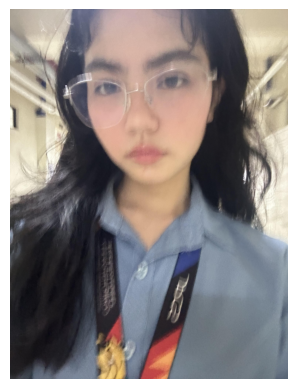

In [37]:
displayImage('/content/drive/My Drive/images_rid/Train/Xen/xenxen.jpg')

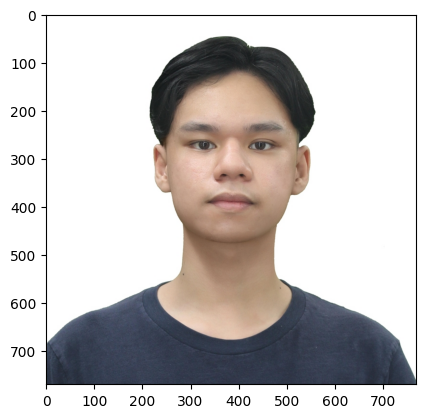

In [14]:
displayImage('/content/drive/My Drive/images_rid/Train/Rid/bbb.jpg')

## 2. Load the images from your drive and apply preprocessing to your raw images

In [15]:

def load_images_from_folder(folder):
    images = []
    labels = []
    for label, person in enumerate(os.listdir(folder)):
        person_folder = os.path.join(folder, person)
        for filename in os.listdir(person_folder):
            img_path = os.path.join(person_folder, filename)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # grayscale
            img = cv2.resize(img, (100, 100))           # resize
            images.append(img.flatten())                # flatten
            labels.append(person)                       # label = folder name
    return np.array(images), np.array(labels)


## 3. Display one pre-processed image from the training set

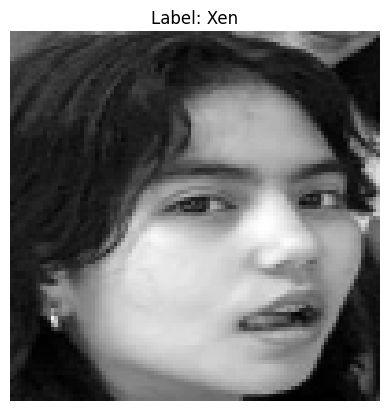

In [17]:
# Load images and labels from the training folder
train_images, train_labels = load_images_from_folder('/content/drive/My Drive/images_rid/Train')

# Display the first pre-processed image
plt.imshow(train_images[0].reshape(100, 100), cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.axis('off')
plt.show()

## 4. Display ten pre-processed images from the training set

In [21]:
train_path = '/content/drive/My Drive/images_rid/Train'
X_train, y_train = load_images_from_folder(train_path)

print("Train set:", X_train.shape, y_train.shape)


Train set: (193, 10000) (193,)


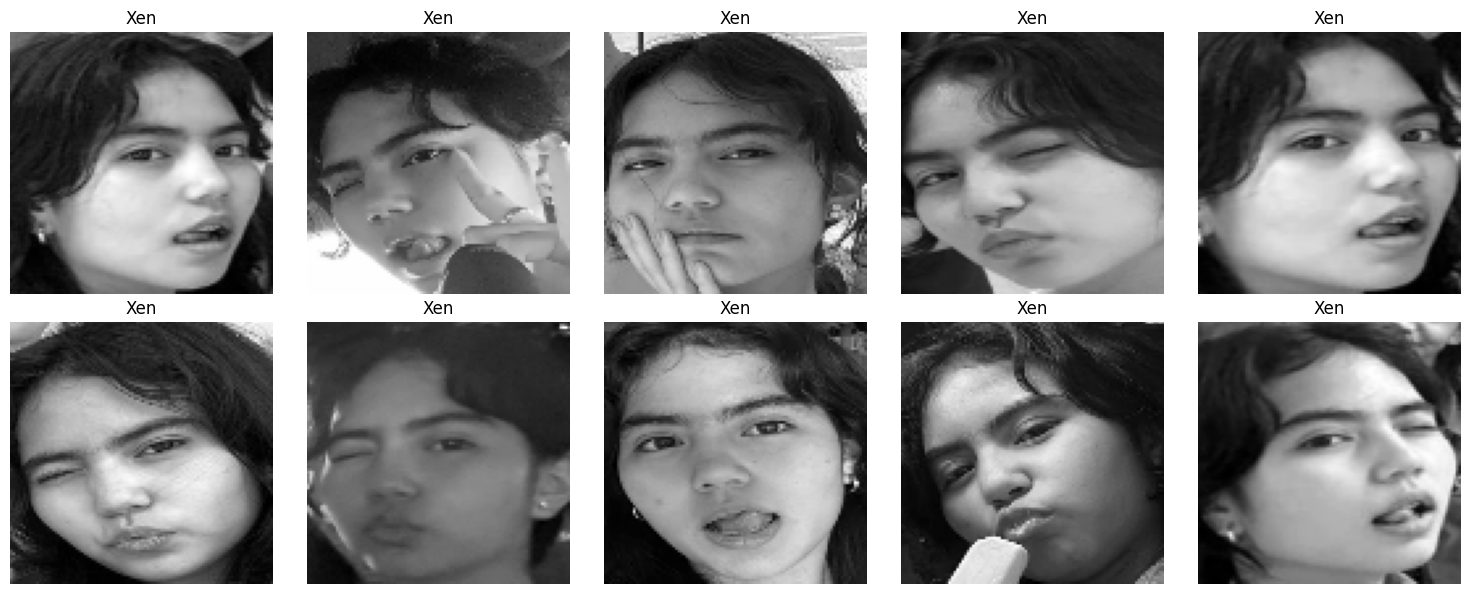

In [22]:
import matplotlib.pyplot as plt

num_faces = 10

fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows and 5 columns
axes = axes.flatten()  # Flatten the array of axes for easy indexing

# Loop to display the images
for i in range(num_faces):
    image = X_train[i].reshape(100, 100)  # Access the i-th image
    name = y_train[i]                     # Get the label

    axes[i].imshow(image, cmap='gray')    # Show the image
    axes[i].set_title(name)               # Set the title
    axes[i].axis('off')                   # Hide axes for cleaner look

plt.tight_layout()
plt.show()


## 5. Split your training data

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

## 6. Train your SVM model

In [27]:
from sklearn import svm

model = svm.SVC(gamma='scale')
model.fit(X_train, y_train)

SVC()

## 7. Evaluate your SVM model

In [28]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 92.31%


## 8. Test your model using images not in your training set

Use your SVM model to predict the label of all of your images in the Test folder

In [32]:
def predict_image(img_path, model):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (100, 100)).flatten().reshape(1, -1)  # Flatten and reshape for prediction
    prediction = model.predict(img)
    return prediction


Predicted label: ['Xen']


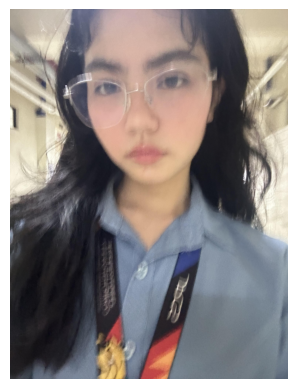

In [38]:
img_path = '/content/drive/My Drive/images_rid/Test/Copy of Copy of IMG_4945.jpg'
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

In [45]:
import os
import pandas as pd
import numpy as np
import cv2

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (100, 100))
    img = img.flatten()       # flatten to 1D
    img = img / 255.0         # normalize if you normalized training data
    return img

test_dir = "/content/drive/My Drive/images_rid/Test"
test_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

predicted_labels = []
filenames = []

for file in test_files:
    img_path = os.path.join(test_dir, file)
    img = preprocess_image(img_path).reshape(1, -1)   # shape = (1, 10000)

    pred = model.predict(img)   # predict with SVM
    label = pred[0]

    filenames.append(file)
    predicted_labels.append(label)

submission_df = pd.DataFrame({
    'Filename': filenames,
    'PredictedLabel': predicted_labels
})

submission_df.to_csv("submission.csv", index=False)
print("✅ Submission file created:", submission_df.shape)


✅ Submission file created: (40, 2)


In [46]:
from google.colab import files
files.download("submission.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>